import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

print("All libraries installed successfully!")

In [13]:
import os
os.getcwd()

'C:\\Users\\ELCOT'

In [2]:
import os
os.listdir()

['.accessibility.properties',
 '.copilot',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.ms-ad',
 '.vscode',
 '.vscode-shared',
 'AppData',
 'Application Data',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'marketing_AB.csv',
 'Marketing_AB_Testing.ipynb',
 'Microsoft',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{14a50da7-ca67-11f0-89f4-388d3dfbb8f7}.TM.blf',
 'NTUSER.DAT{14a50da7-ca67-11f0-89f4-388d3dfbb8f7}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{14a50da7-ca67-11f0-89f4-388d3dfbb8f7}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'Templates',
 'Videos',
 'Zotero']

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("marketing_AB.csv")

In [5]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [6]:
df.shape

(588101, 7)

In [7]:
df.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='str')

In [ ]:
df = df.drop(columns=["Unnamed: 0"])

In [18]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [19]:
df.isnull().sum()

user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user id        588101 non-null  int64
 1   test group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total ads      588101 non-null  int64
 4   most ads day   588101 non-null  str  
 5   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB


In [22]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [23]:
df.describe()

,user id,total ads,most ads hour
count,5.881010e+05,588101.000000,588101.000000
mean,1.310692e+06,24.820876,14.469061
std,2.022260e+05,43.715181,4.834634
min,9.000000e+05,1.000000,0.000000
25%,1.143190e+06,4.000000,11.000000
50%,1.313725e+06,13.000000,14.000000
75%,1.484088e+06,27.000000,18.000000
max,1.654483e+06,2065.000000,23.000000


Hypothesis

Null Hypothesis (H₀):
There is no significant difference in conversion rates between the advertisement group and the control/PSA group.

Alternative Hypothesis (H₁):
There is a significant difference in conversion rates between the advertisement group and the control/PSA group.

Significance Level

α = 0.05

Metric

Our primary metric is:

Conversion Rate = Number of Purchases / Total Users × 100

In [24]:
df.columns

Index(['user id', 'test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='str')

In [25]:
conversion_rate = df.groupby("test group")["converted"].mean() * 100
conversion_rate

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64

In [27]:
import matplotlib.pyplot as plt

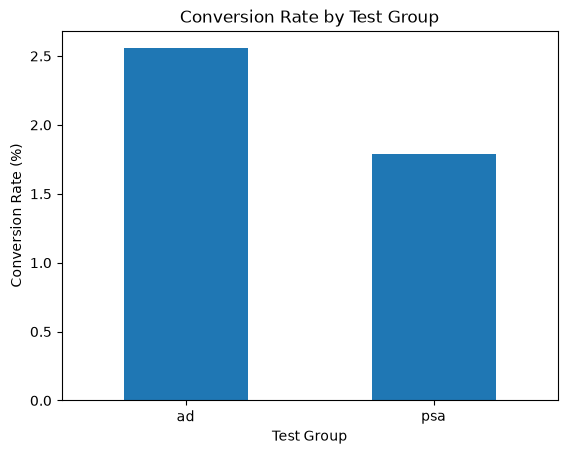

In [28]:
conversion_rate.plot(kind="bar")

plt.title("Conversion Rate by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [30]:
group_counts = df["test group"].value_counts()
group_counts

test group
ad     564577
psa     23524
Name: count, dtype: int64

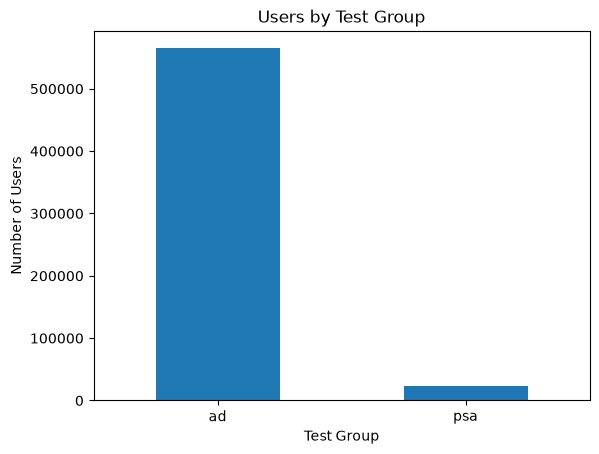

In [31]:
group_counts.plot(kind="bar")

plt.title("Users by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.show()

In [4]:
ad_users = (df["test group"] == "ad").sum()
psa_users = (df["test group"] == "psa").sum()

print("Ad users:", ad_users)
print("PSA users:", psa_users)

NameError: name 'df' is not defined

In [3]:
ad_conversions = df.loc[df["test group"] == "ad", "converted"].sum()
psa_conversions = df.loc[df["test group"] == "psa", "converted"].sum()

print("Ad conversions:", ad_conversions)
print("PSA conversions:", psa_conversions)

NameError: name 'df' is not defined

In [38]:
count = np.array([ad_conversions, psa_conversions])
nobs = np.array([ad_users, psa_users])

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 7.3700781265454145
P-value: 1.7052807161559727e-13


In [35]:
import numpy as np

In [37]:
from statsmodels.stats.proportion import proportions_ztest

In [39]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


In [5]:
ad_rate = ad_conversions / ad_users
psa_rate = psa_conversions / psa_users

difference = ad_rate - psa_rate

se = np.sqrt(
    (ad_rate * (1 - ad_rate) / ad_users) +
    (psa_rate * (1 - psa_rate) / psa_users)
)

margin_error = 1.96 * se

lower = difference - margin_error
upper = difference + margin_error

print("Ad Conversion Rate:", ad_rate * 100, "%")
print("PSA Conversion Rate:", psa_rate * 100, "%")
print("Difference in Conversion Rate:", difference * 100, "%")
print("95% Confidence Interval:", lower * 100, "% to", upper * 100, "%")

NameError: name 'ad_conversions' is not defined

## Business Conclusion

The advertisement group achieved a higher conversion rate of **2.55%** compared with **1.79%** for the PSA group.

The statistical test produced a **p-value of 1.705 × 10⁻¹³**, which is below the 0.05 significance level. Therefore, the null hypothesis is rejected, indicating a statistically significant difference in conversion rates between the two groups.

The **95% confidence interval for the difference in conversion rates is 0.595% to 0.943%**, which remains above zero.

Overall, the analysis shows that the advertisement group had a statistically significant higher conversion rate than the PSA group in this dataset.
